# 01 - EDA: Online Retail

Objetivo: entender patrones de compra, distribucion por pais y horas pico, y documentar que decisiones de modelado/feature engineering se derivan de cada hallazgo.

**Integrante 2 - ML & Feature Engineer**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clean/online_retail_clean.csv", parse_dates=["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 1. Distribucion de ventas por pais

**Decision que depende de esto:** si un pais domina el dataset (ej. UK), evaluar si conviene modelar por separado o si el pais debe entrar como feature/segmento.

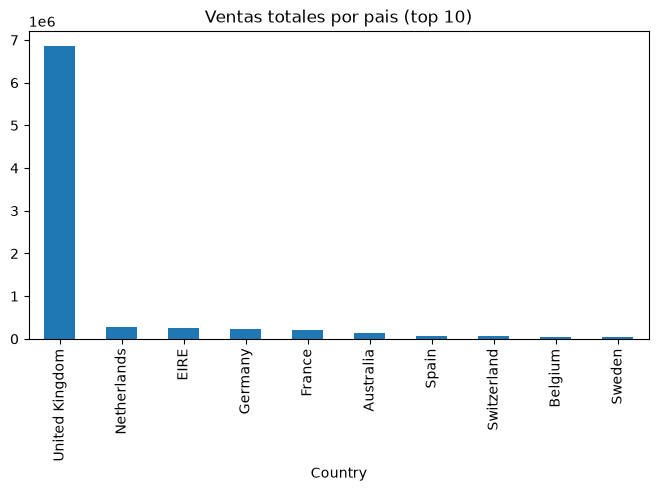

In [2]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
country_sales.head(10).plot(kind="bar", figsize=(8,4), title="Ventas totales por pais (top 10)")
plt.show()

## 2. Horas y dias pico de compra

**Decision que depende de esto:** si hay estacionalidad horaria/semanal fuerte, considerar variables temporales en feature engineering (ej. % compras fin de semana, ya incluida en RFM ampliado).

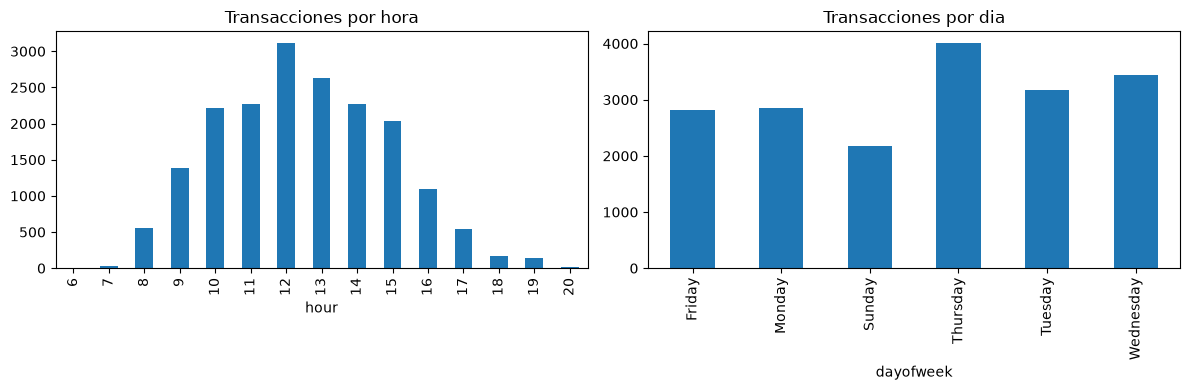

In [3]:
df["hour"] = df["InvoiceDate"].dt.hour
df["dayofweek"] = df["InvoiceDate"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
df.groupby("hour")["InvoiceNo"].nunique().plot(kind="bar", ax=axes[0], title="Transacciones por hora")
df.groupby("dayofweek")["InvoiceNo"].nunique().plot(kind="bar", ax=axes[1], title="Transacciones por dia")
plt.tight_layout()
plt.show()

## 3. Distribucion de gasto por cliente (Monetary)

**Decision que depende de esto:** si la distribucion esta muy sesgada (skewness alta), justifica el StandardScaler o incluso una transformacion log antes de clustering, y ayuda a fijar rangos razonables para las Data Quality Gates de Integrante 1.

Skewness: 20.76708780623394


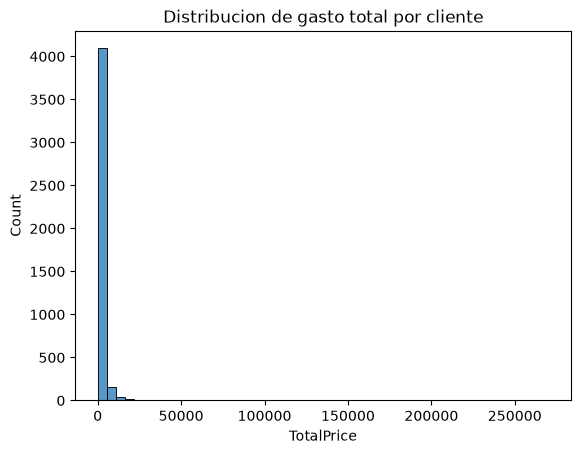

In [4]:
customer_spend = df.groupby("CustomerID")["TotalPrice"].sum()
print("Skewness:", customer_spend.skew())
sns.histplot(customer_spend, bins=50)
plt.title("Distribucion de gasto total por cliente")
plt.show()

## 4. Diversidad de productos y tasa de devoluciones

**Decision que depende de esto:** confirma si estas variables comportamentales (incluidas en `build_features.py`) aportan separacion entre clientes, mas alla de RFM puro.

In [5]:
import sys
sys.path.append("..")
from src.features.build_features import build_customer_features

features, scaler, feature_cols = build_customer_features(df)
features[feature_cols].describe()

,recency,frequency,monetary,monetary_std,return_rate,unique_products,weekend_purchase_pct
count,4330.000000,4330.000000,4330.000000,4330.000000,4330.0,4330.000000,4330.000000
mean,92.508545,4.267206,1946.301747,25.624617,0.0,61.606236,0.132151
std,99.949810,7.670987,8195.858857,340.140971,0.0,85.399240,0.279729
min,1.000000,1.000000,2.900000,0.000000,0.0,1.000000,0.000000
25%,18.000000,1.000000,305.280000,5.839515,0.0,16.000000,0.000000
50%,51.000000,2.000000,664.055000,9.538080,0.0,35.000000,0.000000
75%,142.000000,5.000000,1641.275000,19.027553,0.0,77.750000,0.088515
max,374.000000,209.000000,270283.460000,22226.807784,0.0,1786.000000,1.000000


## Conclusion y decisiones

### Comparacion de los diferentes modelos

| Algoritmo        | Clusters encontrados | Silhouette Score | Davies-Bouldin |
|-------------------|----------------------|-------------------|-----------------|
| K-Means (k=3)      | 3                    | **0.8876**        | 0.5548          |
| K-Means (k=4)      | 4                    | 0.3654            | 0.7745          |
| K-Means (k=5)      | 5                    | 0.4316            | 0.6720          |
| DBSCAN (eps=0.5)   | 1 (todo ruido)       | No calculable     | No calculable   |
| DBSCAN (eps=0.8)   | 2                    | 0.5775            | **0.4148**      |
| Agglomerative (k=3)| 3                    | 0.8589            | 0.6116          |
| Agglomerative (k=4)| 4                    | 0.4069            | 0.7804          |
| Agglomerative (k=5)| 5                    | 0.4154            | 0.7309          |

### Modelo seleccionado: K-Means con k=3

Se selecciona el modelo K-Means (k=3) como el modelo de produccion ya que obtuvo un Silhouette Score mayor o mas alto en las diferentes 8 configuraciones probadas (0.8876, en una escala de -1 a 1 donde valores cercanos a 1 indican clusters bien separados y compactos).

Agglomerative Clustering con k=3 obtuvo un resultado muy cercano (0.8589) y nos indica que: **la estructura natural de los clientes del dataset es explicado mejor con 3 grupos, no con 4 grupos o 5 grupos**. Al usar k=4 o k=5 en ambos algoritmos Silhouette cae drasticamente (de ~0.88 a ~0.40), lo que nos indica que forzar mas grupos de los que existen naturalmente en los datos rompe la cohesion interna de los clusters.

DBSCAN se comporto distinto al resto: con eps=0.5 no encontro estructura (clasifico todo como ruido) y con eps=0.8 solo encontro 2 clusters. Aunque su Davies-Bouldin (0.4148) fue el mejor de la tabla, su Silhouette (0.5775) es notablemente menor que el de K-Means/Agglomerative con k=3, lo que sugiere que los clientes no forman regiones de densidad claramente separadas (como asume DBSCAN), sino grupos mas compactos y esfericos, que es justamente lo que K-Means asume por diseño y es coherente con el resultado obtenido.

### Razones para la toma del modelo K-Means con k=3

- Descartar DBSCAN ya que la naturaleza de las variables RFM (con clientes concentrados en rangos similares de recencia/frecuencia y una cola larga de gasto) por lo que no se genero las zonas de densidad distintas que DBSCAN necesitaba para funcionar bien.
- Se confirma  a k=3 como el numero de segmentos de clientes a usar en produccion, no k=4, no k=5, informandonos que mas grupos no mejoraran la calidad del clustering, y solo lo fragmentan.
- El criterio de seleccion es Silhouette Score como la metrica principal ya que mide que tan bien separados y compactos quedan los clusters y usando Davies-Bouldin como metrica secundaria de referencia mas no como un criterio de desempate contra el Silhouette Socore.
